# Content
---

### **1. Data Preparation**:
- Images are resized to `224x224` and normalized to [0, 1].
- Data is split into training, validation, and test sets.
  
---

### **2. Model Architecture**:
- **Base Model**: VGG16 (pre-trained on ImageNet) with only the convolutional layers (`include_top=False`) for feature extraction. The base model is frozen (non-trainable).
- **Custom Layers**:
  - Flatten layer → Dense(1024, ReLU) → Dropout(30%)
  - Dense(512, ReLU) → Dropout(30%)
  - Dense(256, ReLU) → Dropout(30%)
  - Final Dense(1, Sigmoid) for binary classification.

---

### **3. Training**:
- Loss: Binary Crossentropy
- Optimizer: Adam
- Metrics: Accuracy
- Trained for 10 epochs with a batch size of 32.

---

### **4. Evaluation**:
- Predictions are made on test data.
- Accuracy, recall, precision, F1-score, and a confusion matrix are used for evaluation.

---

### **Model Summary**:
The model leverages the **VGG16** base for feature extraction and adds fully connected layers for classification. It benefits from pre-trained weights to improve accuracy on a small dataset without overfitting.

---

### **Saving (Optional)**:
The model can be saved using:
```python
model.save("cats_dogs_classifier.h5")
```

# Basic setting

### Measuring execution time

In [1]:
!pip install --q ipython-autotime
%load_ext autotime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 27.8 MB/s eta 0:00:00
time: 321 µs (started: 2025-01-23 04:48:39 +00:00)


### Library

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import keras
import os
import requests
import zipfile
import io
import PIL

time: 14.8 s (started: 2025-01-23 04:48:39 +00:00)


# Data collection

### Get zip data from URL

In [3]:
# Data URL
data_url = 'https://raw.githubusercontent.com/20161609/data_box/main/cats_and_dogs.zip'
response = requests.get(data_url)
if response.status_code == 200:
    zip_data = io.BytesIO(response.content)  # Processing in memory
    with zipfile.ZipFile(zip_data, 'r') as zip_ref:
        zip_ref.extractall('/content')  # Decompress in memory

    data_root = '/content/cats_and_dogs'
    train_dir = data_root + '/train'
    test_dir = data_root + '/test'

    # Load the training data
    train_cats_fnames = os.listdir(train_dir + '/cats')
    train_dogs_fnames = os.listdir(train_dir + '/dogs')
else:
    raise Exception(f"Failed to download data. Status code: {response.status_code}")

time: 1.5 s (started: 2025-01-23 04:48:53 +00:00)


In [4]:
class_name = ['cats', 'dogs']
X_train, y_train = [], []

for fname in train_cats_fnames:
    image = PIL.Image.open(train_dir + '/cats/' + fname)
    image = image.resize((224, 224))
    arr = np.array(image)
    X_train.append(arr)
    y_train.append(0)

for fname in train_dogs_fnames:
    image = PIL.Image.open(train_dir + '/dogs/' + fname)
    image = image.resize((224, 224))
    arr = np.array(image)
    X_train.append(arr)
    y_train.append(1)

X_train = np.array(X_train)
y_train = np.array(y_train)

print(type(X_train), type(y_train))
print(X_train.shape, y_train.shape)

<class 'numpy.ndarray'> <class 'numpy.ndarray'>
(2600, 224, 224, 3) (2600,)
time: 15.1 s (started: 2025-01-23 04:48:55 +00:00)


# Data preparation

### Split: train and validation

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2,
                                                  shuffle=True,
                                                  random_state=42)

print(X_train.shape, X_val.shape)
print(y_train.shape, y_val.shape)

(2080, 224, 224, 3) (520, 224, 224, 3)
(2080,) (520,)
time: 1.77 s (started: 2025-01-23 04:49:10 +00:00)


### Show sample image from train data

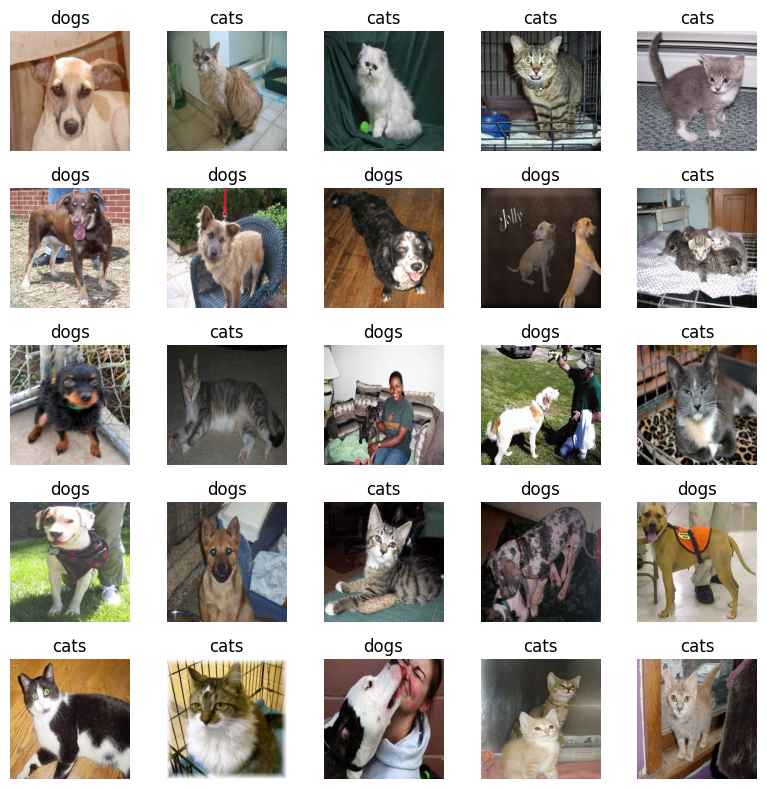

time: 4.75 s (started: 2025-01-23 04:49:12 +00:00)


In [6]:
# np.random.seed(42)
sample = np.random.randint(2080, size=25)

fig = plt.figure(figsize=(8, 8))
for i, idx in enumerate(sample):
    plt.subplot(5, 5, i+1)
    plt.imshow(X_train[idx], cmap='gray')
    plt.axis('off')
    plt.title(class_name[y_train[idx]])
fig.tight_layout()
plt.show()

# Data preprocessing

In [7]:
X_train_s = X_train.astype('float')/255.
X_val_s = X_val.astype('float')/255.

X_train_s.shape, X_val_s.shape

((2080, 224, 224, 3), (520, 224, 224, 3))

time: 2.89 s (started: 2025-01-23 04:49:17 +00:00)


# Model

### Create model

In [8]:
from keras.applications import VGG16

base_model = VGG16(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False
base_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

time: 10.3 s (started: 2025-01-23 04:49:20 +00:00)


In [9]:
from keras import layers

model = keras.Sequential()
model.add(base_model)
model.add(layers.Flatten())
model.add(layers.Dense(1024, activation='relu'))
model.add(layers.Dropout(0.3))
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dropout(0.3))
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.3))
model.add(layers.Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1024)                │      25,691,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 41,062,209 (156.64 MB)

 Trainable params: 26,347,521 (100.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

time: 392 ms (started: 2025-01-23 04:49:30 +00:00)


### Compile model

In [10]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

time: 40 ms (started: 2025-01-23 04:49:30 +00:00)


### History

In [11]:
EPOCHS = 10
BATCH_SIZE = 32

history = model.fit(X_train_s, y_train,
                    epochs=EPOCHS,
                    batch_size=BATCH_SIZE,
                    validation_data=(X_val_s, y_val))

Epoch 1/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 37s 301ms/step - accuracy: 0.6103 - loss: 1.6641 - val_accuracy: 0.8327 - val_loss: 0.3474
Epoch 2/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 16s 159ms/step - accuracy: 0.8737 - loss: 0.3048 - val_accuracy: 0.9096 - val_loss: 0.2317
Epoch 3/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 21s 170ms/step - accuracy: 0.9251 - loss: 0.1807 - val_accuracy: 0.8788 - val_loss: 0.2968
Epoch 4/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 21s 173ms/step - accuracy: 0.9383 - loss: 0.1472 - val_accuracy: 0.9058 - val_loss: 0.2644
Epoch 5/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 20s 170ms/step - accuracy: 0.9620 - loss: 0.0853 - val_accuracy: 0.9154 - val_loss: 0.2955
Epoch 6/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 20s 169ms/step - accuracy: 0.9734 - loss: 0.0668 - val_accuracy: 0.8731 - val_loss: 0.5508
Epoch 7/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 21s 178ms/step - accuracy: 0.9653 - loss: 0.0997 - val_accuracy: 0.9231 - val_loss: 0.3003
Epoch 8/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 20s 177ms/step - accuracy: 0.9863 - loss: 0.0469 - val_accu

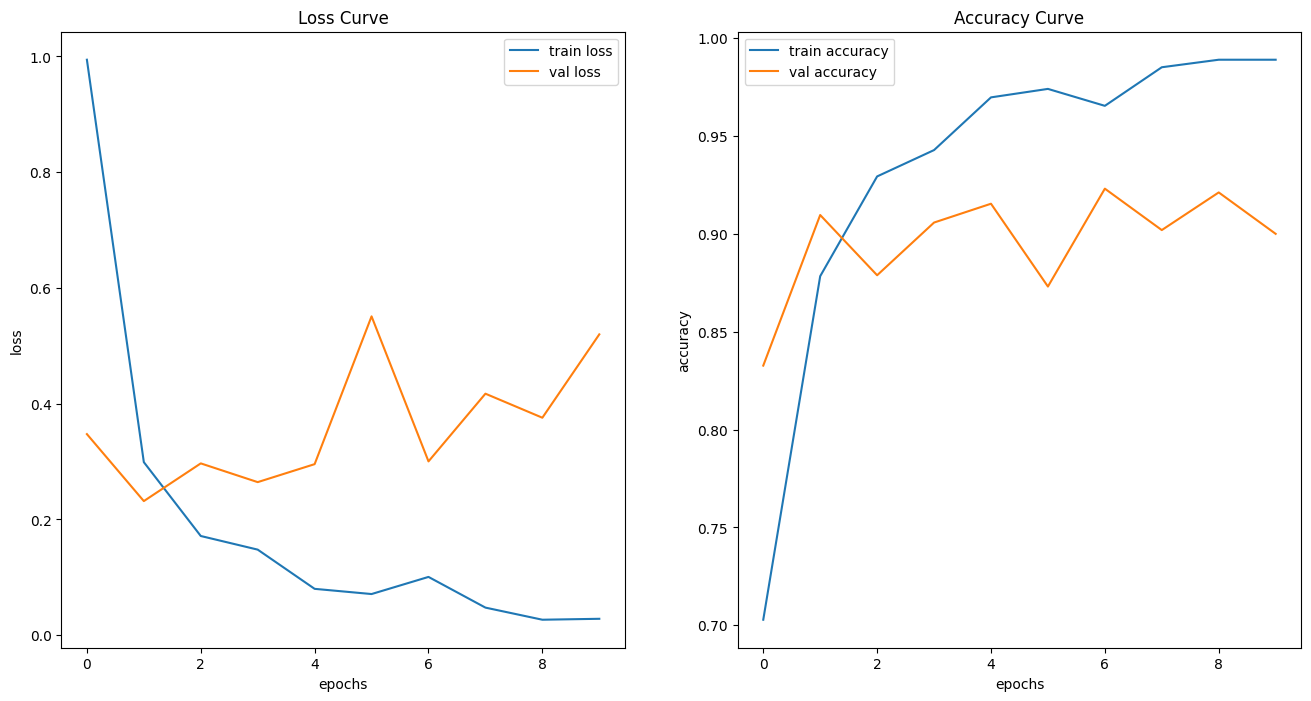

time: 388 ms (started: 2025-01-23 04:53:15 +00:00)


In [12]:
def plot_history(history):
    hist = pd.DataFrame(history.history)
    hist['epoch'] = history.epoch

    plt.figure(figsize=(16, 8))
    plt.subplot(1, 2, 1)
    plt.xlabel('epochs')
    plt.ylabel('loss')
    plt.plot(hist['epoch'], hist['loss'], label='train loss')
    plt.plot(hist['epoch'], hist['val_loss'], label='val loss')
    plt.title('Loss Curve')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.xlabel('epochs')
    plt.ylabel('accuracy')
    plt.plot(hist['epoch'], hist['accuracy'], label='train accuracy')
    plt.plot(hist['epoch'], hist['val_accuracy'], label='val accuracy')
    plt.title('Accuracy Curve')
    plt.legend()
    plt.show()

plot_history(history)

# Estimate

### Get test data

In [13]:
# Data preprocessing
test_cats_fnames = os.listdir(test_dir + '/cats')
test_dogs_fnames = os.listdir(test_dir + '/dogs')

X_test = []
y_test = []

for fname in test_cats_fnames:
    image = PIL.Image.open(test_dir + '/cats/' + fname)
    image = image.resize((224, 224))
    arr = np.array(image)
    X_test.append(arr)
    y_test.append(0)

for fname in test_dogs_fnames:
    image = PIL.Image.open(test_dir + '/dogs/' + fname)
    image = image.resize((224, 224))
    arr = np.array(image)
    X_test.append(arr)
    y_test.append(1)

X_test = np.array(X_test)
y_test = np.array(y_test)

# Normalization of test data
X_test_s = X_test.astype('float') / 255.

X_test.shape, y_test.shape

((400, 224, 224, 3), (400,))

time: 2.08 s (started: 2025-01-23 04:53:16 +00:00)


### Get prediction

In [14]:
y_pred_proba = model.predict(X_test_s)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

y_pred.shape

13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 864ms/step


(400,)

time: 14.3 s (started: 2025-01-23 04:53:18 +00:00)


### Show perfomance from test data

accuracy: 0.8875
recall: 0.81
precision: 0.9585798816568047
f1 : 0.8780487804878049


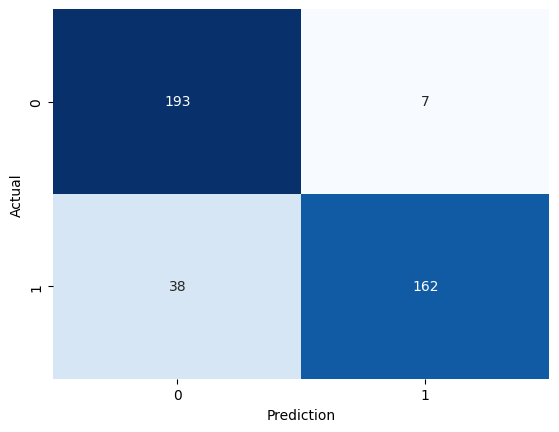

time: 97.1 ms (started: 2025-01-23 04:53:32 +00:00)


In [15]:
from sklearn.metrics import accuracy_score, recall_score, precision_score,f1_score
from sklearn.metrics import confusion_matrix

def print_metrics(y_true, y_pred, aver='binary'):
    print('accuracy:', accuracy_score(y_true, y_pred))
    print('recall:', recall_score(y_true, y_pred ,average=aver))
    print('precision:', precision_score(y_true, y_pred,average=aver))
    print('f1 :', f1_score(y_true, y_pred, average=aver))

    cfm = confusion_matrix(y_true, y_pred)
    s = sns.heatmap(cfm, annot=True, cmap='Blues', fmt='d', cbar=False)
    s.set(xlabel='Prediction', ylabel='Actual')
    plt.show()

print_metrics(y_test, y_pred)